# Module 5 Lab 1: Chart It, Then Test It

**CS 82A - Introduction to Data Science**

**Ramisha Tasfia**

**GitHub:** [https://github.com/ramishatasfia5156-commits/cs82a-coursework/blob/main/module5/module5_lab.ipynb](https://github.com/ramishatasfia5156-commits/cs82a-coursework/blob/main/module5/module5_lab.ipynb)

## Setup

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

sns.set_theme(style="whitegrid")
print("Libraries loaded: seaborn", sns.__version__)

Libraries loaded: seaborn 0.13.2


## Step 1: Group means for chick feeds

In [2]:
chicks = pd.read_csv("chickwts.csv")
feed_means = chicks.groupby("feed")["weight"].mean().sort_values()
print(feed_means.round(1))

feed
horsebean    160.2
linseed      218.8
soybean      246.4
meatmeal     276.9
casein       323.6
sunflower    328.9
Name: weight, dtype: float64


## Step 2: Sorted bar chart (order = lowest to highest mean)

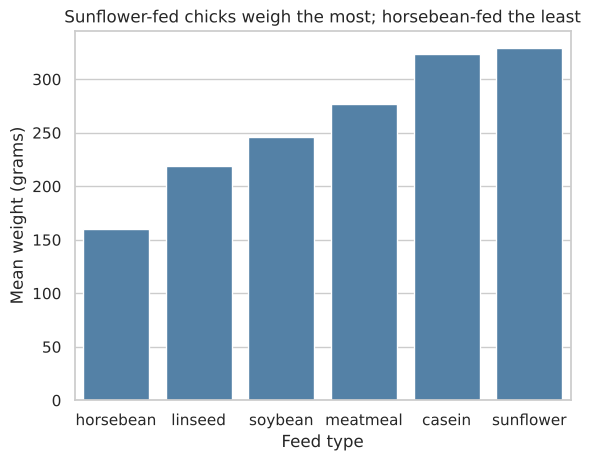

In [3]:
sns.barplot(data=chicks, x="feed", y="weight", order=feed_means.index,
            errorbar=None, color="steelblue")
plt.title("Sunflower-fed chicks weigh the most; horsebean-fed the least")
plt.xlabel("Feed type")
plt.ylabel("Mean weight (grams)")
plt.ylim(bottom=0)
plt.show()

## Step 3: Histogram of all weights

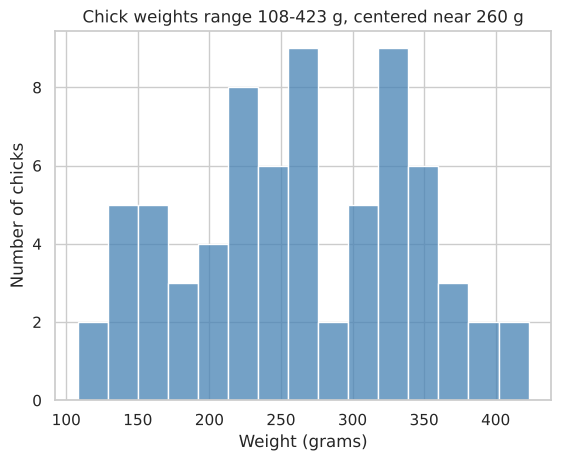

In [4]:
sns.histplot(data=chicks, x="weight", bins=15, color="steelblue")
plt.title("Chick weights range 108-423 g, centered near 260 g")
plt.xlabel("Weight (grams)")
plt.ylabel("Number of chicks")
plt.show()

## Step 4: Line chart of museum visitors

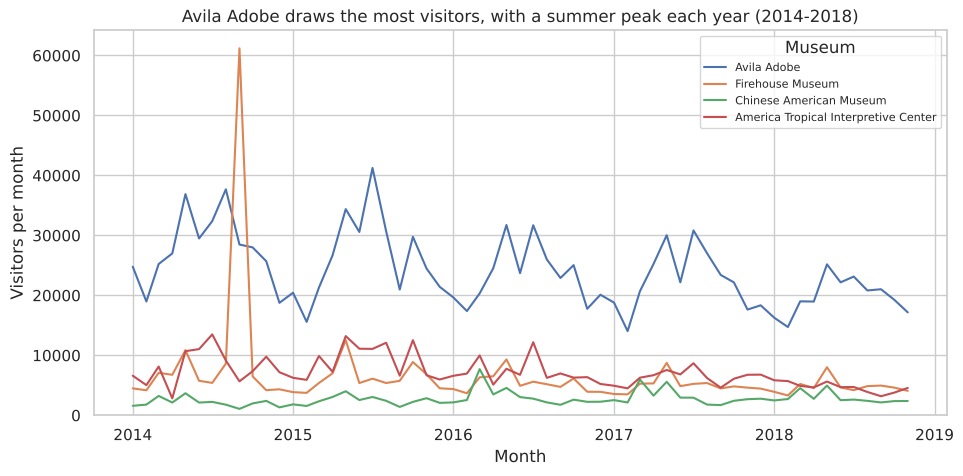

In [5]:
museum = pd.read_csv("museum_visitors.csv", parse_dates=["Date"])
museum_long = museum.melt(id_vars="Date", var_name="Museum", value_name="Visitors")

plt.figure(figsize=(11, 5))
sns.lineplot(data=museum_long, x="Date", y="Visitors", hue="Museum")
plt.title("Avila Adobe draws the most visitors, with a summer peak each year (2014-2018)")
plt.xlabel("Month")
plt.ylabel("Visitors per month")
plt.ylim(bottom=0)
plt.legend(title="Museum", fontsize=8)
plt.show()
# Note: Firehouse Museum's Sept 2014 spike (61,192) is a one-month outlier.

**Observed trend:** Avila Adobe draws far more visitors than the other three museums every month, peaking each May and July, but its average monthly attendance fell about 29% from 2014 to 2018 (≈27,800 → ≈19,800). Firehouse Museum's September 2014 spike (61,192 visitors) is a one-month outlier, not a trend.

## Step 5a: Load Module 4 sales data and build revenue

In [6]:
sales = pd.read_csv("sales_clean.csv")
print("Rows with negative qty (returns or entry errors):", (sales["qty"] < 0).sum())
sales = sales[sales["qty"] > 0].copy()          # drop invalid negative quantities
sales["revenue"] = sales["price"] * sales["qty"]
print(sales[["price", "qty", "revenue"]].describe().round(2))

Rows with negative qty (returns or entry errors): 3
        price     qty  revenue
count  289.00  289.00   289.00
mean    55.72    2.98   161.94
std     72.11    1.41   235.96
min      2.93    1.00     3.33
25%     10.97    2.00    30.75
50%     37.53    3.00    75.06
75%     56.38    4.00   189.60
max    479.29    5.00  1708.85


## Step 5b: Scatter qty vs. revenue

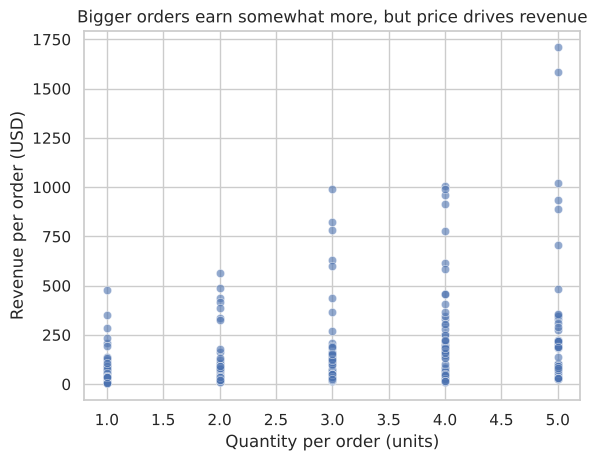

In [7]:
sns.scatterplot(data=sales, x="qty", y="revenue", alpha=0.6)
plt.title("Bigger orders earn somewhat more, but price drives revenue")
plt.xlabel("Quantity per order (units)")
plt.ylabel("Revenue per order (USD)")
plt.show()

## Step 5c: Correlation heatmap

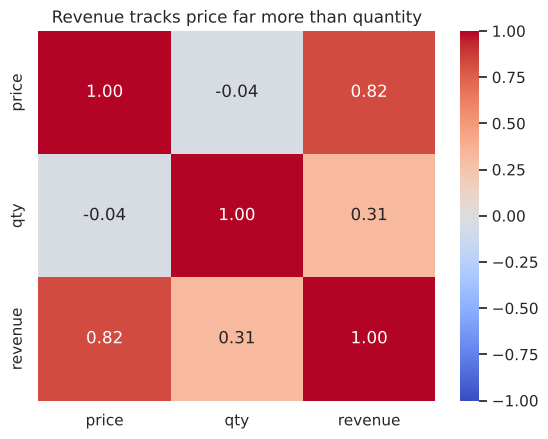

         price   qty  revenue
price     1.00 -0.04     0.82
qty      -0.04  1.00     0.31
revenue   0.82  0.31     1.00


In [8]:
corr = sales[["price", "qty", "revenue"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Revenue tracks price far more than quantity")
plt.show()
print(corr.round(2))

**Strongest off-diagonal correlation:** The strongest off-diagonal correlation is found for price/revenue, where the strength of that relationship is r = .82. This represents a strong positive relationship. The relationship for quantity/revenue is weak to moderate by comparison (r = .31), and there is virtually no relationship between price and quantity (r = -.04). In the data set examined here, the value of revenue was primarily influenced by what customers purchased rather than how many units were ordered. Prior to producing charts, three orders had negative values for quantity (orders #1140, 1233, and 1025); I removed those from the data set. Revenue = price × quantity; the column variables `order_id` and `zip` were omitted from the heatmap since both represent identifiers and not measurement variables.

## Step 6: Null hypothesis
H<sub>0</sub>: There is no difference in mean weight between chicks fed sunflower feed versus those fed horsebean feed (μ<sub>sunflower</sub> = μ<sub>horsebean</sub>).

## Step 7: t-test, sunflower vs. horsebean

In [9]:
sunflower = chicks[chicks["feed"] == "sunflower"]["weight"]
horsebean = chicks[chicks["feed"] == "horsebean"]["weight"]
print("n sunflower:", len(sunflower), "| n horsebean:", len(horsebean))

result = ttest_ind(sunflower, horsebean)
diff = sunflower.mean() - horsebean.mean()
print(f"Mean sunflower: {sunflower.mean():.1f} g")
print(f"Mean horsebean: {horsebean.mean():.1f} g")
print(f"Difference (effect size): {diff:.1f} g")
print(f"t = {result.statistic:.2f}, p = {result.pvalue:.2e}")

n sunflower: 12 | n horsebean: 10
Mean sunflower: 328.9 g
Mean horsebean: 160.2 g
Difference (effect size): 168.7 g
t = 8.85, p = 2.37e-08


## Step 8: Conclusion
Sunflower-fed chicks weighed on average 168.7 grams more than horsebean-fed chicks (328.9 g vs. 160.2 g; t = 8.85, p = 2.37 × 10<sup>-8</sup>); therefore, I reject the null hypothesis. However, because the sample size was limited to only twelve and ten chicks from a single data set, the results may not be generalizable to other farms and/or different feeding environments.

## Step 9: Honest-chart audit
In regards to creating the feed bar chart, I made two choices for honesty. The first choice was making sure the y-axis began at zero. This makes it possible for the bar heights to represent the actual mean weights and does not exaggerate the differences between the feeds. The second choice was labeling the y-axis with units ("Mean weight (grams)"). By doing this, the reader will know exactly what is being measured and will be able to read the correct values off of the graph. A limitation is that although the chart represents averages, it does not show how variable individual chicks were within each feed.

## AI Disclosure
 Claude (Anthropic) was used to help explain concepts and draft the code for this lab. All code was reviewed and understood by me, and I rewrote the written responses in my own words. I can explain why each chart needs a takeaway title and unit-bearing axes, why price drives revenue far more than quantity in the heatmap, how the t-test compares sunflower-fed and horsebean-fed chick weights, and why a 168.7 g difference with p = 2.37 × 10<sup>-8</sup> leads me to reject the null hypothesis.

Key prompt: "Help me with Module 5 Lab 1: Chart It, Then Test It using the attached data."